# ONLINE RETAIL SMALL E COM CHECKDATA2

In [5]:
import pandas as pd
df=pd.read_excel("C:/-----SEM4-----/projects/data eng/dataset/Online Retail.xlsx")

In [6]:
df.to_csv("C:/-----SEM4-----/projects/data eng/dataset/Online Retail.csv",index='False')
#since excel files takes a lot of time to load i have converted it to csv files and later we will start looking at the dataset

In [7]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [8]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
#now first let us check are there any null values in every column
print("no of null values in INVOICE NO:" , df["InvoiceNo"].isnull().sum())
print("no of null values in INVOICE Date:", df["InvoiceDate"].isnull().sum())
print("no of null values in Stockcode: " , df["StockCode"].isnull().sum())
print("no of null values in Description: " , df["Description"].isnull().sum())
print("no of null values in Quantity: " , df["Quantity"].isnull().sum())
print("no of null values in Unitprice: " , df["UnitPrice"].isnull().sum())
print("no of null values in Customer ID: " , df["CustomerID"].isnull().sum())
print("no of null values in Country: " , df["Country"].isnull().sum())


no of null values in INVOICE NO: 0
no of null values in INVOICE Date: 0
no of null values in Stockcode:  0
no of null values in Description:  1454
no of null values in Quantity:  0
no of null values in Unitprice:  0
no of null values in Customer ID:  135080
no of null values in Country:  0


ok when we checked as u can see there are (1454/541909) ~ 0.26% .null values in description and
(1,35,000 /5,41,909) ~ 24.9% null values in customer id

since 0.26 percent is very low might have we would drop it completely

In [11]:
dfcl_null = df
dfcl_null=dfcl_null[(dfcl_null["Description"]==0) & (dfcl_null["CustomerID"]== 0 )]
dfcl_null.shape
dfcl_null.head
#hence i might as well drop those null values

<bound method NDFrame.head of Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country]
Index: []>

In [12]:
dfcl=df
dfcl["Description"]=dfcl["Description"].fillna("no description")
print("previous rows before null:",df.shape)
print("after rows after dropping null:",dfcl.shape)
print("description null:",dfcl['Description'].isnull().sum())
dfcl=dfcl.dropna(subset=["CustomerID"])
print("customer id null:", dfcl["CustomerID"].isnull().sum())


previous rows before null: (541909, 8)
after rows after dropping null: (541909, 8)
description null: 0
customer id null: 0


-now we have  cleared the null values by filling description with no description and dropping null values of customer id
 cus if customer id is null there is no point of storing it cus with out it how do we know wether the customer is legit or not it is bad case
 2. now lets check duplicate values

In [13]:
print("no of duplicate values in INVOICE NO:" , dfcl["InvoiceNo"].duplicated().sum())
print("no of duplicate values in INVOICE Date:", dfcl["InvoiceDate"].duplicated().sum())
print("no of duplicate values in Stockcode: " , dfcl["StockCode"].duplicated().sum())
#print("no of duplicate values in Description: " , dfcl["Description"].duplicated.sum())
print("no of duplicate values in Quantity: " , dfcl["Quantity"].duplicated().sum())
print("no of duplicate values in Unitprice: " , dfcl["UnitPrice"].duplicated().sum())
print("no of duplicate values in Customer ID: " , dfcl["CustomerID"].duplicated().sum())
print("no of duplicate values in Country: " , dfcl["Country"].duplicated().sum())


no of duplicate values in INVOICE NO: 384639
no of duplicate values in INVOICE Date: 386369
no of duplicate values in Stockcode:  403145
no of duplicate values in Quantity:  406393
no of duplicate values in Unitprice:  406209
no of duplicate values in Customer ID:  402457
no of duplicate values in Country:  406792


In [14]:
print(dfcl["CustomerID"].unique().shape)
#as previously we saw duplicate value of customerid as 402457 but here there are only 4372 unique id that indicates these id people
#have been  regular customers or have been ordering more from the same online retail store
print(dfcl["InvoiceNo"].unique())

(4372,)
[536365 536366 536367 ... 581585 581586 581587]


In [15]:
#now as gpt said check wether rows are duplicated
print("exact rows duplicated are:",dfcl.duplicated().sum())
duplicates = dfcl[dfcl.duplicated(keep=False)]
duplicates.sort_values(["InvoiceNo", "StockCode", "InvoiceDate"]
).head(30)


exact rows duplicated are: 5225


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [16]:
same_product = dfcl[
    (dfcl["InvoiceNo"] == 536409) &
    (dfcl["StockCode"] == 21866)
]

print(same_product)
dfcl[dfcl["InvoiceNo"] == 536409]

    InvoiceNo StockCode                  Description  Quantity  \
494    536409     21866  UNION JACK FLAG LUGGAGE TAG         1   
517    536409     21866  UNION JACK FLAG LUGGAGE TAG         1   

            InvoiceDate  UnitPrice  CustomerID         Country  
494 2010-12-01 11:45:00       1.25     17908.0  United Kingdom  
517 2010-12-01 11:45:00       1.25     17908.0  United Kingdom  


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
483,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,3,2010-12-01 11:45:00,6.35,17908.0,United Kingdom
484,536409,21479,WHITE SKULL HOT WATER BOTTLE,1,2010-12-01 11:45:00,3.75,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
486,536409,22785,SQUARECUSHION COVER PINK UNION FLAG,1,2010-12-01 11:45:00,6.75,17908.0,United Kingdom
487,536409,22975,SPACEBOY CHILDRENS EGG CUP,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
488,536409,22972,CHILDREN'S SPACEBOY MUG,1,2010-12-01 11:45:00,1.65,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
490,536409,22568,FELTCRAFT CUSHION OWL,1,2010-12-01 11:45:00,3.75,17908.0,United Kingdom
491,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
492,536409,22664,TOY TIDY DOLLY GIRL DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom


Exact duplicate rows were identified. However, identical records may represent repeated quantities of the same product within a single invoice rather than erroneous duplication. Since the dataset does not provide a unique transaction-line identifier, these records cannot confidently be classified as data-entry duplicates. Therefore, they were retained to avoid potentially underestimating sales quantity and revenue.

dfcl_backup1=dfcl

In [17]:
dfcl_backup1=dfcl
dfcl.columns
dfcl["Description"].unique()

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER', ...,
       'PINK CRYSTAL SKULL PHONE CHARM',
       'CREAM HANGING HEART T-LIGHT HOLDER',
       'PAPER CRAFT , LITTLE BIRDIE'], shape=(3896,), dtype=object)

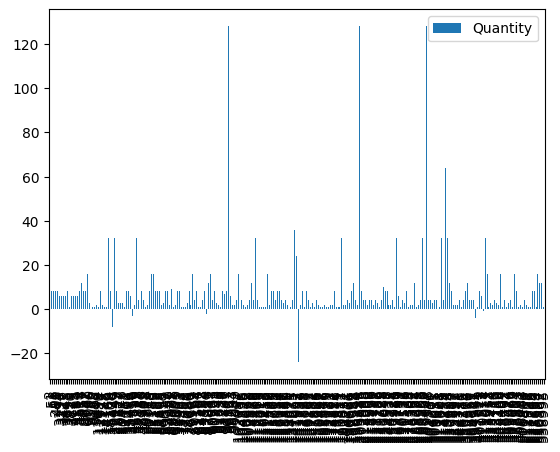

In [18]:
check = dfcl.loc[
    (dfcl["Description"] == "PINK CRYSTAL SKULL PHONE CHARM") |
    (dfcl["Description"] == "CREAM CUPID HEARTS COAT HANGER"),
    ["InvoiceNo", "Description", "Quantity"]
].plot(kind='bar')


In [19]:
print(dfcl.shape)
print(df.shape)

(406829, 8)
(541909, 8)


In [20]:
dfcl.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [21]:
uni=dfcl["StockCode"].value_counts()
uni2=dfcl["StockCode"].info
print(uni2)

<bound method Series.info of 0         85123A
1          71053
2         84406B
3         84029G
4         84029E
           ...  
541904     22613
541905     22899
541906     23254
541907     23255
541908     22138
Name: StockCode, Length: 406829, dtype: object>


dfcl

In [22]:
dfcl["Description"].unique 
dfcl.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Axes(0.125,0.11;0.775x0.77)


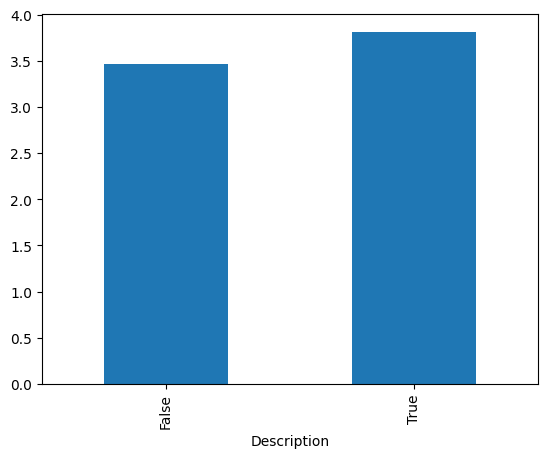

In [23]:
products = [
    "WHITE METAL LANTERN",
    "CREAM CUPID HEARTS COAT HANGER"
]

cmp2= dfcl.loc[
    dfcl["Description"].isin(products),
    ["InvoiceNo", "Description"]]
print(dfcl.groupby(dfcl["Description"]=="CREAM CUPID HEARTS COAT HANGER")["UnitPrice"].mean().plot(kind='bar'))

In [24]:
#now to understand relations between two numeric maybe use groupby
dfcl.groupby("Country")["Quantity"].describe()

,count,mean,std,min,25%,50%,75%,max
Country,,,,,,,,
Australia,1259.0,66.444003,97.686932,-120.0,6.00,24.0,96.0,1152.0
Austria,401.0,12.037406,21.745485,-48.0,6.00,9.0,12.0,288.0
Bahrain,17.0,15.294118,24.959379,2.0,6.00,6.0,8.0,96.0
Belgium,2069.0,11.189947,13.601441,-12.0,4.00,10.0,12.0,272.0
Brazil,32.0,11.125000,8.476723,2.0,3.00,10.0,18.0,24.0
Canada,151.0,18.298013,46.682587,1.0,6.00,12.0,20.0,504.0
Channel Islands,758.0,12.505277,22.570877,-2.0,4.00,10.0,12.0,407.0
Cyprus,622.0,10.155949,23.263590,-33.0,2.00,5.0,12.0,288.0
Czech Republic,30.0,19.733333,22.813990,-24.0,12.00,24.0,24.0,72.0


In [25]:
dfcl[["Quantity","UnitPrice"]].corr()

,Quantity,UnitPrice
Quantity,1.000000,-0.001238
UnitPrice,-0.001238,1.000000


In [26]:
dfcl["revenue"] = dfcl["Quantity"]*dfcl["UnitPrice"]


C:\Users\moksh\AppData\Local\Temp\ipykernel_14428\2568277554.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfcl["revenue"] = dfcl["Quantity"]*dfcl["UnitPrice"]


<Axes: xlabel='Description'>

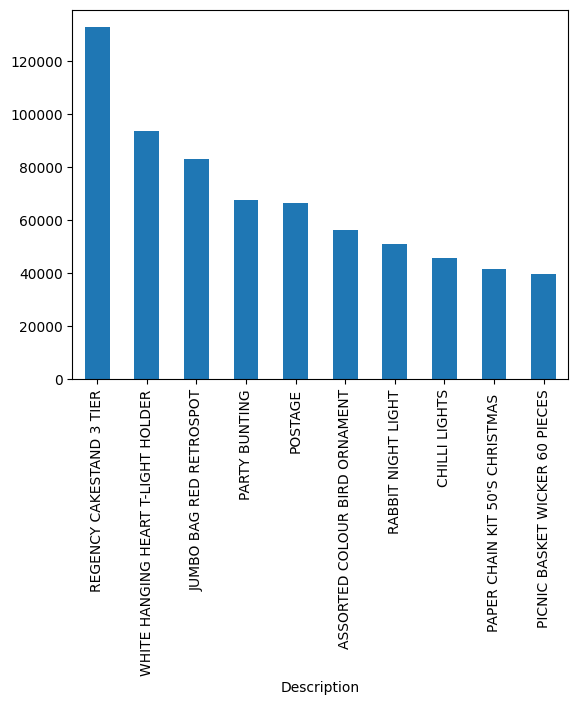

In [27]:
dfcl.groupby("Description")["revenue"].sum().sort_values(ascending=False).head(10).plot(kind='bar')


In [36]:
#Which country has the highest average order value, excluding the United Kingdom?
non_uk= dfcl.loc[dfcl["Country"] != "United Kingdom"]
non_uk.groupby(["InvoiceNo","Country"])["revenue"].sum().sort_values(ascending=False).reset_index().head(10)

,InvoiceNo,Country,revenue
0,556917,Australia,22775.93
1,563614,Australia,21880.44
2,572035,Netherlands,20277.92
3,563076,Netherlands,19150.66
4,541220,EIRE,16774.72
5,545475,Australia,16726.84
6,548011,Netherlands,15719.56
7,569650,Australia,15643.77
8,552883,Netherlands,14415.74
9,543989,Australia,14022.92


In [42]:
print(dfcl.columns)
dfcl["Country"].unique()

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'revenue'],
      dtype='object')


array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

In [ ]:
#Which 5 customers from France generated the highest total revenue, and how many unique products did each of those customers purchase?
only_france= dfcl.loc[dfcl["Country"]=="France"]
q2=only_france.groupby(["CustomerID","Country","Description"])["revenue"].sum().sort_values(ascending=False).head(5)
print(q2.reset_index())
hha51318

   CustomerID Country                    Description  revenue
0     12678.0  France             RABBIT NIGHT LIGHT  2362.80
1     12731.0  France  ASSORTED COLOUR BIRD ORNAMENT  1565.60
2     12682.0  France             RABBIT NIGHT LIGHT  1541.04
3     12681.0  France                        POSTAGE  1368.00
4     12682.0  France                        POSTAGE  1260.00


In [71]:
#Which 5 products generated the most revenue in Germany among customers who purchased more than 10 units in a transaction?
only_german=dfcl.loc[(dfcl["Country"]=="Germany") &(dfcl["Quantity"] > 10)]
only_german.groupby(["Description"])["revenue"].sum().sort_values(ascending = False).head(5).reset_index()

,Description,revenue
0,REGENCY CAKESTAND 3 TIER,7621.2
1,ROUND SNACK BOXES SET OF4 WOODLAND,2598.9
2,SPACEBOY LUNCH BOX,1615.8
3,PLASTERS IN TIN WOODLAND ANIMALS,1386.0
4,6 RIBBONS RUSTIC CHARM,1308.6


           Country  CustomerID
0          Belgium          25
1          Austria          11
2        Australia           9
3  Channel Islands           9
4          Denmark           9
5           Cyprus           8
6           Canada           4
7          Bahrain           2
8           Brazil           1
9   Czech Republic           1


<Axes: >

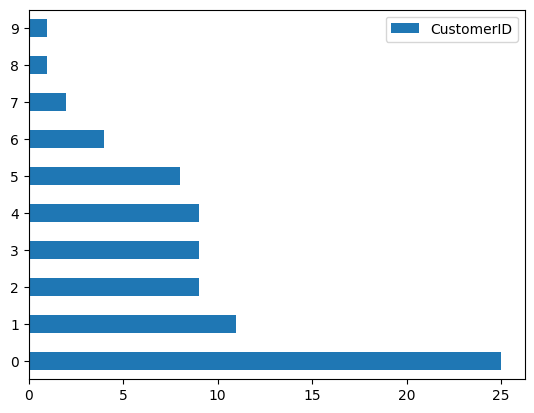

In [87]:
nw=dfcl.groupby("Country")["CustomerID"].nunique().head(10).sort_values(ascending=False).reset_index()
print(nw)
nw.plot(kind='barh')

In [95]:
#Which country has the highest average quantity purchased per invoice?
dfcl.groupby(["Country"])["Quantity"].mean().reset_index().head(5)

,Country,Quantity
0,Australia,66.444003
1,Austria,12.037406
2,Bahrain,15.294118
3,Belgium,11.189947
4,Brazil,11.125000


In [96]:
#now lets the the correlation in quantity and unit price
dfcl.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'revenue'],
      dtype='object')

In [97]:
dfcl[["Quantity","UnitPrice"]].corr()

,Quantity,UnitPrice
Quantity,1.000000,-0.001238
UnitPrice,-0.001238,1.000000


- as we can see the unit quantity and unitprice has false negative relation ship therefore hence we cant say with increase in quantity ...unit ptice also increases therefore there is not much relation init

dfcl.columns()

In [99]:
dfcl.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'revenue'],
      dtype='object')

In [110]:
dfcl["Country"].nunique()
#currently as of  now there only 37 unique countries
dfcl["Country"].unique()
dfcl.shape

(406829, 9)

In [111]:
only_saudiarabia = dfcl.loc[(dfcl["Country"]=="Saudi Arabia") ]
only_saudiarabia.groupby(["Country","CustomerID"])["revenue"].sum().sort_values(ascending=False).head(10).reset_index()

,Country,CustomerID,revenue
0,Saudi Arabia,12565.0,131.17


out of 40.6829 rows we have only one saudi arabia which is kinda weird is it that the current website didnt flourish in over that region or it must have recieved a real bad reviews previously for the people to stop using


ok now lets leave saudi arabia and check the avg price in every other country iguess


In [139]:
exc_saudi=dfcl.loc[dfcl["Country"] == "Saudi Arabia"]
exc_saudi.groupby(["Country","InvoiceNo","Description"])["Quantity"].sum().reset_index()

,Country,InvoiceNo,Description,Quantity
0,Saudi Arabia,544838,ASSORTED BOTTLE TOP MAGNETS,12
1,Saudi Arabia,544838,GLASS JAR DAISY FRESH COTTON WOOL,6
2,Saudi Arabia,544838,GLASS JAR MARMALADE,6
3,Saudi Arabia,544838,GLASS JAR PEACOCK BATH SALTS,6
4,Saudi Arabia,544838,GOLD EAR MUFF HEADPHONES,2
5,Saudi Arabia,544838,HOMEMADE JAM SCENTED CANDLES,12
6,Saudi Arabia,544838,PLASTERS IN TIN CIRCUS PARADE,12
7,Saudi Arabia,544838,PLASTERS IN TIN SKULLS,12
8,Saudi Arabia,544838,PLASTERS IN TIN STRONGMAN,12
9,Saudi Arabia,C545507,GLASS JAR DAISY FRESH COTTON WOOL,-5


-bro wtf there is an non-named-country brooo jesus who even made this dataset my gawd fuck u bro

In [132]:
pd.crosstab(dfcl["StockCode"],dfcl["Description"],margins=True)

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY,All
StockCode,,,,,,,,,,,,,,,,,,,,,
10002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,49
10080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,21
10120,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,30
10125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,64
10133,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DOT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,16
M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,465
PADS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


- as we can see description and stock code  it is too fucked upp

In [144]:
nocun=dfcl.loc[dfcl["Country"] == "Unspecified"]
nocun.groupby(["Country","Description","UnitPrice"])["revenue"].nunique().reset_index()


,Country,Description,UnitPrice,revenue
0,Unspecified,SPACEBOY BABY GIFT SET,16.95,1
1,Unspecified,12 MESSAGE CARDS WITH ENVELOPES,1.65,2
2,Unspecified,18PC WOODEN CUTLERY SET DISPOSABLE,1.25,1
3,Unspecified,200 RED + WHITE BENDY STRAWS,1.25,1
4,Unspecified,3 STRIPEY MICE FELTCRAFT,1.95,2
...,...,...,...,...
209,Unspecified,WRAP POPPIES DESIGN,0.42,1
210,Unspecified,WRAP SUKI AND FRIENDS,0.42,1
211,Unspecified,WRAP VINTAGE PETALS DESIGN,0.42,1
212,Unspecified,WRAP WEDDING DAY,0.42,1
